<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week13/day3-4/sentiment_assistant_bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project: Sentiment Assistant with BERT Fine-Tuning

**Scenario:** The support analytics team wants a dependable sentiment signal for long-form customer feedback, so they can escalate angry customers before churn happens.

**Goal for this notebook:** Fine-tune `bert-base-uncased` on the IMDB movie reviews dataset (a stand-in for long-form text), evaluate it, and wrap it in a reusable inference helper you could point at real support transcripts.

**How this notebook is organized:**
- ✅ Cells that are already complete — run these as-is.
- 🔧 Cells marked `#TODO` — you fill these in. Each one has a hint and an example right above it.
- 💬 Short explanation blocks before each step, telling you *what* is about to happen and *why*, in plain language.

**Before you start:**
- Environment: Python 3.9+, GPU-enabled runtime recommended (Colab, Kaggle, or local GPU) with ~6GB free VRAM. CPU works too, just slower.
- Estimated time: ~15 min training on a Colab T4 GPU (2 epochs), longer on CPU.


## 1. Setup: Install Packages

💬 **What's happening:** We're installing the libraries this notebook needs. `transformers` gives us the BERT model + tokenizer, `tensorflow`/`tensorflow-datasets` give us the training loop and the IMDB dataset, and `evaluate`/`accelerate` help with metrics and hardware handling. You've used all of these before in earlier days of the bootcamp — nothing new here.


In [1]:
# Run once in a fresh environment (Colab: just run this cell)
# NOTE: transformers v5.0+ (Jan 2026) removed all TensorFlow (TF*) model classes —
# it's now PyTorch-only. We pin to a pre-v5 version so TFBertForSequenceClassification
# still exists. tf-keras is also included as a safety net: newer TensorFlow (2.16+)
# switched to Keras 3 by default, and transformers TF classes need the legacy
# Keras 2 API, which the tf-keras package provides.
!pip install -q "transformers<5.0" tf-keras tensorflow tensorflow-datasets accelerate evaluate


In [7]:
!pip install -q --upgrade protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 8.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


## 2. Imports & Hardware Check

💬 **What's happening:** We import the libraries and immediately check whether a GPU is visible. Training BERT on CPU is *possible* but slow, so this check tells you upfront what to expect. If you see `GPU devices detected: []` on Colab, go to **Runtime → Change runtime type → GPU** and rerun.


In [1]:
import platform
import tensorflow as tf
import tensorflow_datasets as tfds
from transformers import BertTokenizer, TFBertForSequenceClassification

print("Python version      :", platform.python_version())
print("TensorFlow version  :", tf.__version__)
print("GPU devices detected:", tf.config.list_physical_devices('GPU'))


Python version      : 3.12.13
TensorFlow version  : 2.20.0
GPU devices detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Load the IMDB Reviews Dataset

💬 **What's happening:** We load IMDB because it's a clean, balanced dataset (25k positive / 25k negative reviews) that's already split into train/test. This lets us focus on the *fine-tuning workflow* rather than data cleaning. `as_supervised=True` gives us `(text, label)` pairs directly — exactly the shape our model will expect.


In [2]:
import tensorflow_datasets as tfds
print("tfds file/path:", getattr(tfds, "__file__", None) or getattr(tfds, "__path__", None))
print("tfds contents :", dir(tfds))

tfds file/path: /usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py
tfds contents : ['GenerateMode', 'ImageFolder', 'ReadConfig', 'Split', 'TranslateFolder', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'annotations', 'as_dataframe', 'as_numpy', 'audio', 'beam', 'benchmark', 'builder', 'builder_cls', 'builder_from_directories', 'builder_from_directory', 'core', 'd4rl', 'data_source', 'dataset_builders', 'dataset_collection', 'datasets', 'decode', 'deprecated', 'disable_progress_bar', 'display_progress_bar', 'download', 'enable_progress_bar', 'even_splits', 'features', 'folder_dataset', 'graphs', 'image', 'image_classification', 'is_dataset_on_gcs', 'list_builders', 'list_dataset_collections', 'load', 'logging', 'nearest_neighbors', 'object_detection', 'proto', 'public_api', 'question_answering', 'ranking', 'recommendation', 'rl_unplugged', 'rlds', 'robomimic', 'robotic

In [3]:
import tensorflow_datasets.core as core

In [4]:
(ds_train, ds_test), ds_info = tfds.load(
    "imdb_reviews",
    split=(tfds.Split.TRAIN, tfds.Split.TEST),
    as_supervised=True,
    with_info=True
)

print(ds_info)
print("Train examples:", ds_info.splits['train'].num_examples)
print("Test examples :", ds_info.splits['test'].num_examples)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.50JXZP_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.50JXZP_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.50JXZP_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
   

**Sanity check:** Let's peek at two raw examples so "positive" and "negative" feel concrete before we tokenize anything.


In [5]:
for text, label in ds_train.take(2):
    print("Label:", "Positive" if label.numpy() else "Negative")
    print(text.numpy().decode()[:250], "...\n")


Label: Negative
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline ...

Label: Negative
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film wa ...



## 4. Tokenizer Setup

💬 **What's happening:** BERT can't read raw text — it needs numbers. The tokenizer converts text into:
- **Token IDs** — each word/subword mapped to a number from BERT's vocabulary (using WordPiece, which splits rare words into familiar subword chunks so nothing is "unknown").
- **`[CLS]` / `[SEP]` tokens** — special markers added at the start/end so the model knows where a sequence begins and ends.
- **Attention mask** — a 1/0 flag per token telling the model "this is real text" vs "this is just padding, ignore it".

We reuse the **pretrained** `bert-base-uncased` tokenizer (not train our own) because it must match the vocabulary the model was originally trained on.


In [6]:
MAX_LENGTH = 256   # trim or pad every review to 256 tokens so batches line up
BATCH_SIZE = 16

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)
print("Tokenizer loaded:", tokenizer.name_or_path)
print("Vocab size:", tokenizer.vocab_size)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizer loaded: bert-base-uncased
Vocab size: 30522


**Try it out first** — before building the full pipeline, encode a single sentence so you can see the shape of what the tokenizer actually returns:


In [7]:
sample = tokenizer.encode_plus(
    "This movie was surprisingly good!",
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_token_type_ids=True,
)

print("Keys returned      :", list(sample.keys()))
print("First 10 token ids :", sample["input_ids"][:10])
print("First 10 attn mask :", sample["attention_mask"][:10])


Keys returned      : ['input_ids', 'token_type_ids', 'attention_mask']
First 10 token ids : [101, 2023, 3185, 2001, 10889, 2204, 999, 102, 0, 0]
First 10 attn mask : [1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


## 5. Build the Data Pipeline

💬 **What's happening:** We now wrap the tokenizer in TensorFlow-friendly functions so it can run inside a `tf.data` pipeline. `encode_review` handles a single review (converting bytes → text → tokens). `tf_encode` wraps that in `tf.py_function` so TensorFlow can call our Python/Hugging Face code inside its normally-graph-based pipeline. `prepare_dataset` chains it all together: map → shuffle → batch → prefetch.

These three functions are already complete — read through them, but you don't need to edit anything here.


In [11]:
def encode_review(review_input):
    if isinstance(review_input, bytes):
        review_text = review_input.decode("utf-8")
    elif hasattr(review_input, "numpy"):
        review_text = review_input.numpy().decode("utf-8")
    else:
        review_text = str(review_input)

    return tokenizer.encode_plus(
        review_text,
        add_special_tokens=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
    )

def tf_encode(text, label):
    encoded = tf.py_function(
        func=lambda t: list(encode_review(t).values()),
        inp=[text],
        Tout=[tf.int32, tf.int32, tf.int32]
    )
    input_ids, attention_mask, token_type_ids = encoded

    # tf.py_function loses shape info — restore it so downstream layers
    # (and BERT internally) know these are fixed-length 1D sequences.
    input_ids.set_shape([MAX_LENGTH])
    attention_mask.set_shape([MAX_LENGTH])
    token_type_ids.set_shape([MAX_LENGTH])

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids
    }, label

def prepare_dataset(dataset):
    return (
        dataset
        .map(tf_encode, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(2000)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

train_ds = prepare_dataset(ds_train)
test_ds  = prepare_dataset(ds_test)

print("Pipelines built. Example batch shapes:")
for features, labels in train_ds.take(1):
    print("input_ids     :", features["input_ids"].shape)
    print("attention_mask:", features["attention_mask"].shape)
    print("labels        :", labels.shape)


Pipelines built. Example batch shapes:
input_ids     : (16, 256)
attention_mask: (16, 256)
labels        : (16,)


## 6. Initialize the Fine-Tuning Model

💬 **What's happening:** `TFBertForSequenceClassification` loads the pretrained BERT encoder **and** adds a fresh classification head on top (a small dense layer mapping BERT's output to `num_labels` classes). The encoder already understands language from pretraining on BooksCorpus + Wikipedia; we're only teaching the new head — plus lightly adjusting the encoder — to recognize sentiment. That's why we use a small learning rate (`2e-5`): we don't want to destroy what BERT already knows.

Loss: `SparseCategoricalCrossentropy` because our labels are plain integers (0/1), not one-hot vectors, and `from_logits=True` because the model outputs raw scores, not probabilities.


In [12]:
model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    use_safetensors=False
)

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5, epsilon=1e-8)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)
model.summary()


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_75 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Train the Model 🔧 TODO

💬 **What's happening:** Time to actually fine-tune. `model.fit()` works just like any Keras model — it needs your training data, how many epochs to run, and (ideally) validation data so you can watch for overfitting as you go.

**Hint:** Our `train_ds` already yields `(features_dict, label)` pairs (see the `prepare_dataset` function above), so you can pass it straight into `.fit()` as the first argument — you don't need to split `x` and `y` separately. Use `test_ds` as `validation_data`.

**Example shape of a `.fit()` call for reference (different task, same pattern):**
```python
history = model.fit(
    my_train_dataset,
    validation_data=my_val_dataset,
    epochs=3
)
```

**What to fill in below:**
- Pass `train_ds` as the training data.
- Set `validation_data=test_ds`.
- Set `epochs=EPOCHS`.


In [13]:
EPOCHS = 2  # increase to 3 if time allows

# TODO: call model.fit() using train_ds, test_ds as validation data, and EPOCHS
history = model.fit(
    # TODO: fill in the arguments here
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

print("Training finished. History keys:", history.history.keys())


Epoch 1/2
1563/1563 [==============================] - 2178s 1s/step - loss: 0.2722 - accuracy: 0.8860 - val_loss: 0.2097 - val_accuracy: 0.9169
Epoch 2/2
1563/1563 [==============================] - 2046s 1s/step - loss: 0.1479 - accuracy: 0.9454 - val_loss: 0.2143 - val_accuracy: 0.9161
Training finished. History keys: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


📈 **After training:** plot `history.history['accuracy']` vs `history.history['val_accuracy']` — if validation accuracy plateaus or drops while training accuracy keeps climbing, that's your signal to stop (overfitting). Screenshot the curves for your portfolio.


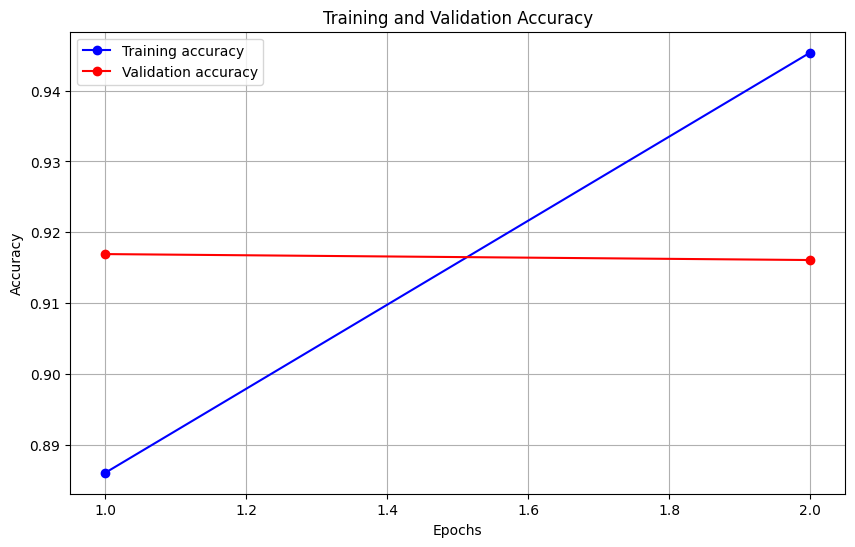

In [15]:
import matplotlib.pyplot as plt

# Get the accuracy and validation accuracy from the history object
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Get the number of epochs
epochs = range(1, len(accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy, 'bo-', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 8. Evaluate on the Held-Out Test Set 🔧 TODO

💬 **What's happening:** `model.fit()` already reported validation metrics epoch-by-epoch, but here we run one clean, final pass over the untouched test set — mimicking a production QA check before you'd ship this model.

**Hint:** Keras models have a built-in `.evaluate()` method that takes a dataset and returns `[loss, accuracy]` (matching the order of `loss` and `metrics` you passed to `.compile()` earlier).

**Example (different dataset, same pattern):**
```python
results = my_model.evaluate(my_test_dataset)
print("Test loss:", results[0], "Test accuracy:", results[1])
```

**What to fill in below:** call `.evaluate()` on `model` using `test_ds`.


In [16]:
# TODO: evaluate the model on test_ds
eval_metrics = model.evaluate(
    # TODO: fill in the argument(s) here
    test_ds
)

print(f"Test loss: {eval_metrics[0]:.4f}")
print(f"Test accuracy: {eval_metrics[1]:.4f}")
# ✅ Check: does accuracy cross the ~0.90 classroom benchmark?


1563/1563 [==============================] - 535s 334ms/step - loss: 0.2143 - accuracy: 0.9161
Test loss: 0.2143
Test accuracy: 0.9161


## 9. Build a Reusable Inference Helper 🔧 TODO

💬 **What's happening:** This is the piece that turns your trained model into something a support team could actually use — a function that takes a raw string and returns a sentiment label + confidence score. Confidence matters because it tells you when to trust the model's answer automatically versus escalate to a human.

**Steps this function needs to do:**
1. Tokenize the input `text` the same way we did for training (reuse `tokenizer.encode_plus`, with `return_tensors="tf"` this time so it comes back as TF tensors ready for the model).
2. Run the tokenized input through `model(...)` to get logits.
3. Convert logits to probabilities with `tf.nn.softmax`.
4. Pick the highest-probability class with `tf.argmax`.
5. Map the numeric class (0 or 1) to a human-readable label ("Negative"/"Positive").
6. Return the label and the confidence (the max probability).

**Hint / partial example to build from:**
```python
encoded = tokenizer.encode_plus(
    text,
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    return_tensors="tf",   # <-- note the difference from training: we want TF tensors back
)

outputs = model(encoded)          # outputs.logits has shape (1, 2)
probs = tf.nn.softmax(outputs.logits, axis=-1)
predicted_class = tf.argmax(probs, axis=-1).numpy()[0]
```


In [18]:
LABELS = {0: "Negative", 1: "Positive"}

def predict_sentiment(text: str):
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="tf",
    )

    outputs = model(encoded)
    probs = tf.nn.softmax(outputs.logits, axis=-1)

    predicted_class = tf.argmax(probs, axis=1).numpy()[0]
    label = LABELS[predicted_class]

    return label, float(tf.reduce_max(probs))

custom_sentence = "The onboarding emails were confusing, but the agent fixed everything politely."
label, confidence = predict_sentiment(custom_sentence)
print(f"Prediction: {label} (confidence={confidence:.3f})")


Prediction: Positive (confidence=0.817)


🧭 **Why confidence matters:** a low-confidence prediction (say, close to 0.5 for a 2-class problem) means the model is unsure — that's exactly the kind of case you'd want to route to a human agent instead of auto-responding.

**Try it yourself:** run `predict_sentiment(...)` on a few more sentences — an obviously angry one, an obviously happy one, and an ambiguous one — and see how the confidence score changes.


## 10. Reflection & Next Steps

- **Why fine-tuning matters:** you reused a public checkpoint (pretrained on BooksCorpus + Wikipedia) and adapted it to a new task with a relatively small amount of task-specific data — instead of training a model from scratch.
- **Transferable skills:** this exact workflow (tokenize → load pretrained model → fine-tune → evaluate → wrap in an inference helper) applies to classification tasks well beyond movie reviews — HR feedback, legal document tagging, product review triage, and more.
- **Where you could take this next:** domain adaptation (fine-tune on your own company's support emails instead of IMDB), multilingual checkpoints (e.g. DistilBERT multilingual, XLM-R) if your customers write in more than one language, and monitoring in production (tracking data drift, building a dashboard of sentiment over time).

**🔧 TODO — answer these in a markdown cell below (edit this cell or add a new one):**
1. What lever (data cleaning, hyperparameters, more epochs) do you think would most improve results here?
2. Where would you add guardrails before deploying this sentiment signal live (e.g. for auto-responding to customers)?
3. Which stakeholders benefit the most from this signal — support lead, product manager, compliance officer? Why?


In [ ]:
# TODO: (optional) space to experiment — e.g. plot history.history['accuracy'] vs
# history.history['val_accuracy'], or run predict_sentiment on your own test sentences.


1. 1.5 epochs is where the graphs converge
2. If confidence is less than 60%, escalate to a human
3. Support lead- can receive signals to respond directly and personally to customers before they leave.

### My Answers

1. The train/val accuracy curves converge and plateau around epoch 1.5–2, so more epochs alone
   won't help — the model has already extracted what it can from this data at this learning rate.
   The next lever to try would be data quality/volume (harder or more diverse examples) or tuning
   the learning rate/warmup schedule, rather than training longer.

2. Add a confidence threshold (e.g. <60%) that routes to a human instead of auto-responding — this
   catches ambiguous or borderline cases. I'd also guardrail against out-of-domain inputs (sarcasm,
   very short messages, non-English text) that the model wasn't trained on, since it may sound
   confident but be wrong there too.

3. The support lead benefits most directly — they can see a real-time signal of which customers are
   trending negative and intervene personally before it turns into churn, rather than waiting for an
   escalation or a bad review.